In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:

df = pd.read_csv("StudentPerformanceFactors.csv")


In [3]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
df.shape
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

np.int64(0)

In [5]:
missing = df.isnull().sum()

missing_percentage = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percentage
})

missing_table = missing_table[missing_table['Missing Values'] > 0]

missing_table

,Missing Values,Percentage
Teacher_Quality,78,1.180566
Parental_Education_Level,90,1.362192
Distance_from_Home,67,1.014076


In [6]:
print("Teacher Quality:")
print(df["Teacher_Quality"].value_counts(dropna=False))

print("\nParental Education Level:")
print(df["Parental_Education_Level"].value_counts(dropna=False))

print("\nDistance from Home:")
print(df["Distance_from_Home"].value_counts(dropna=False))

Teacher Quality:
Teacher_Quality
Medium    3925
High      1947
Low        657
NaN         78
Name: count, dtype: int64

Parental Education Level:
Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
NaN               90
Name: count, dtype: int64

Distance from Home:
Distance_from_Home
Near        3884
Moderate    1998
Far          658
NaN           67
Name: count, dtype: int64


In [7]:
df["Teacher_Quality"].fillna(
    df["Teacher_Quality"].mode()[0],
    inplace=True
)

df["Parental_Education_Level"].fillna(
    df["Parental_Education_Level"].mode()[0],
    inplace=True
)

df["Distance_from_Home"].fillna(
    df["Distance_from_Home"].mode()[0],
    inplace=True
)

/tmp/ipykernel_834/3279332622.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Teacher_Quality"].fillna(
/tmp/ipykernel_834/3279332622.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col

In [8]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [9]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


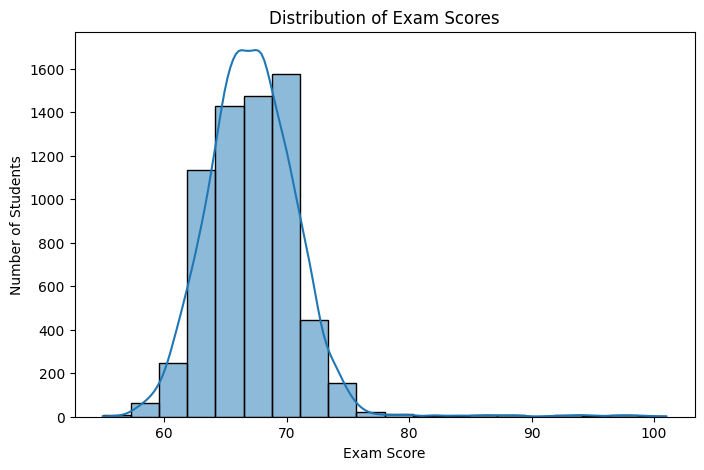

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["Exam_Score"], bins=20, kde=True)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.show()

In [11]:
print("Average Exam Score:", df["Exam_Score"].mean())
print("Median Exam Score:", df["Exam_Score"].median())
print("Minimum Exam Score:", df["Exam_Score"].min())
print("Maximum Exam Score:", df["Exam_Score"].max())

Average Exam Score: 67.23565914938702
Median Exam Score: 67.0
Minimum Exam Score: 55
Maximum Exam Score: 101


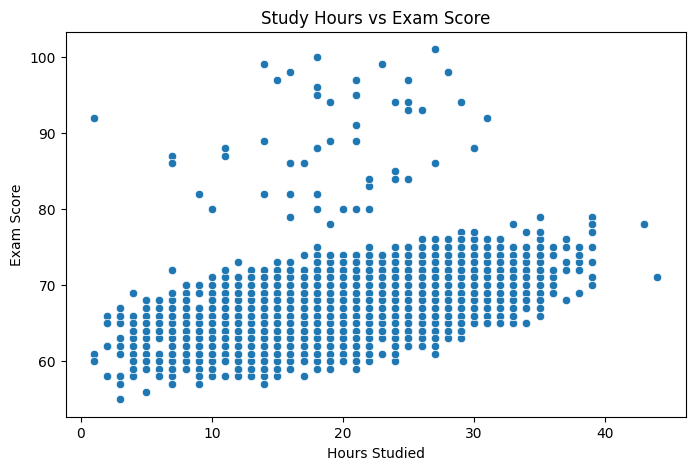

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Hours_Studied",
    y="Exam_Score"
)

plt.title("Study Hours vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.show()

In [13]:
correlation = df["Hours_Studied"].corr(df["Exam_Score"])

print("Correlation between Hours Studied and Exam Score:", correlation)

Correlation between Hours Studied and Exam Score: 0.44545495407528235


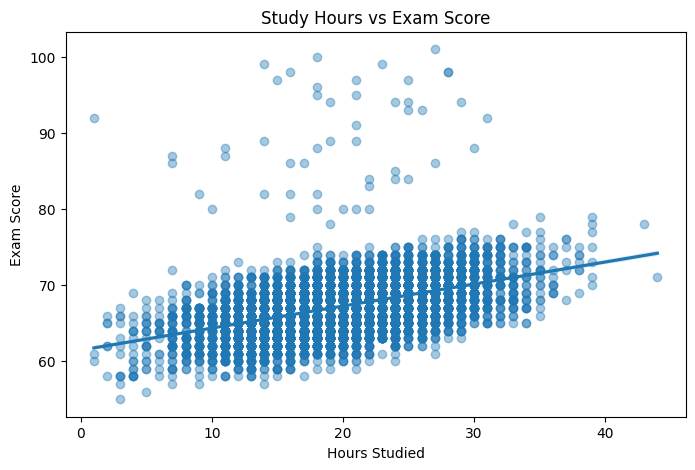

In [14]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="Hours_Studied",
    y="Exam_Score",
    scatter_kws={"alpha": 0.4}
)

plt.title("Study Hours vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.show()

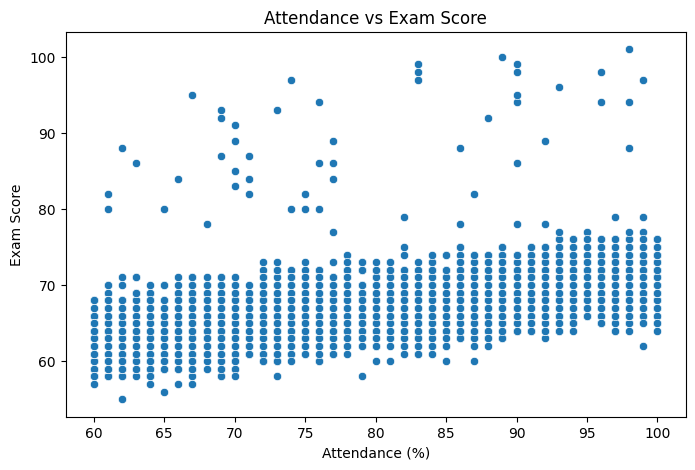

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Attendance",
    y="Exam_Score"
)

plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")

plt.show()

In [16]:
attendance_corr = df["Attendance"].corr(df["Exam_Score"])

print("Correlation between Attendance and Exam Score:", attendance_corr)

Correlation between Attendance and Exam Score: 0.5810718633120645


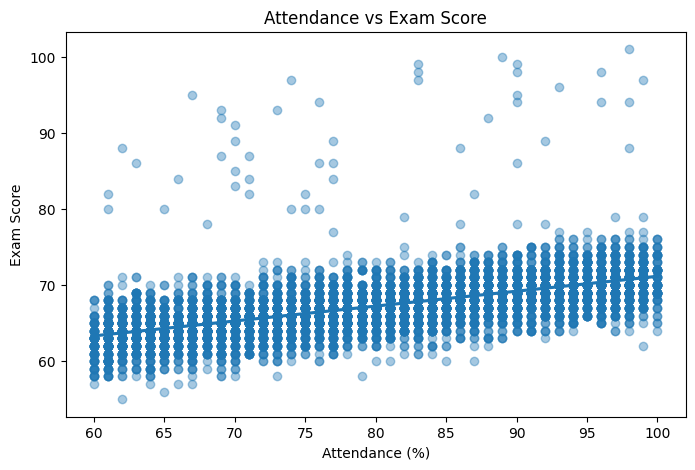

In [17]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="Attendance",
    y="Exam_Score",
    scatter_kws={"alpha": 0.4}
)

plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")

plt.show()

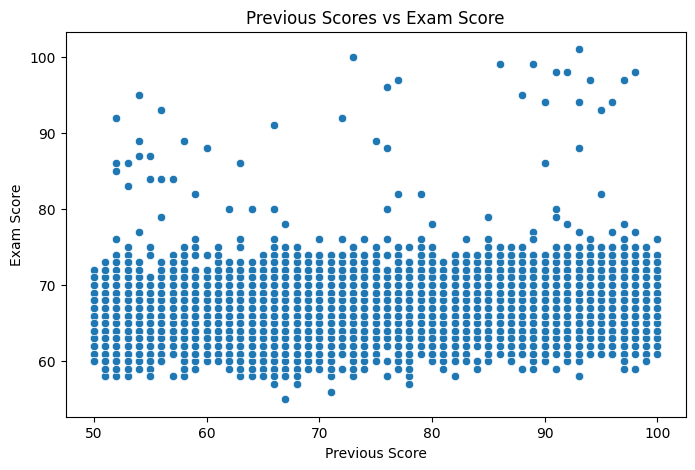

In [18]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Previous_Scores",
    y="Exam_Score"
)

plt.title("Previous Scores vs Exam Score")
plt.xlabel("Previous Score")
plt.ylabel("Exam Score")

plt.show()

In [19]:
previous_score_corr = df["Previous_Scores"].corr(df["Exam_Score"])

print(
    "Correlation between Previous Scores and Exam Score:",
    previous_score_corr
)

Correlation between Previous Scores and Exam Score: 0.17507908702291106


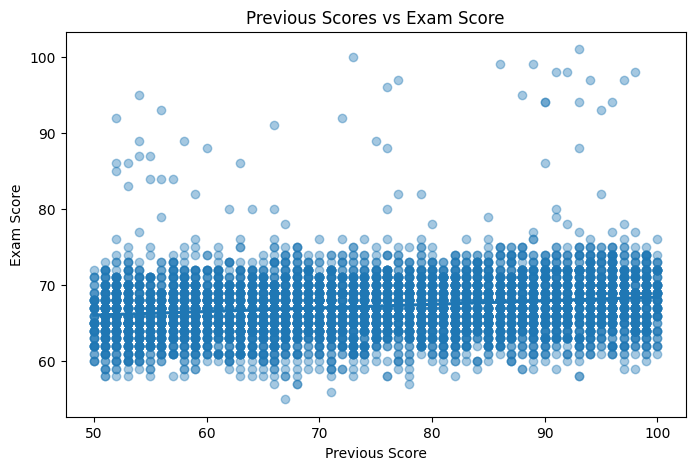

In [20]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="Previous_Scores",
    y="Exam_Score",
    scatter_kws={"alpha": 0.4}
)

plt.title("Previous Scores vs Exam Score")
plt.xlabel("Previous Score")
plt.ylabel("Exam Score")

plt.show()

In [21]:
parental_education_scores = df.groupby(
    "Parental_Education_Level"
)["Exam_Score"].mean().sort_values(ascending=False)

print(parental_education_scores)

Parental_Education_Level
Postgraduate    67.970881
College         67.315737
High School     66.897978
Name: Exam_Score, dtype: float64


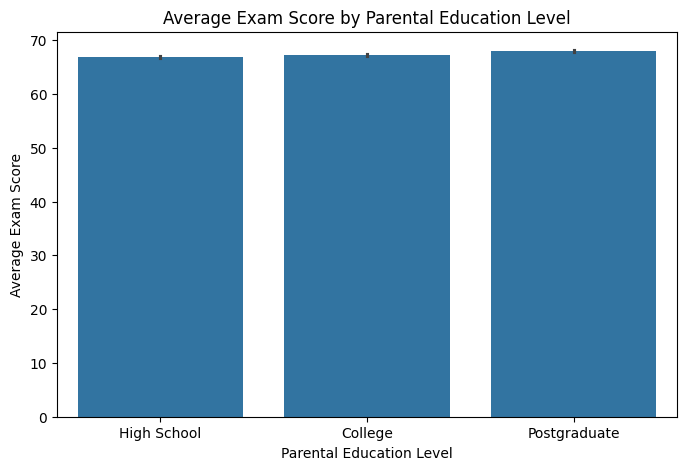

In [22]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Parental_Education_Level",
    y="Exam_Score",
    estimator="mean"
)

plt.title("Average Exam Score by Parental Education Level")
plt.xlabel("Parental Education Level")
plt.ylabel("Average Exam Score")

plt.show()

In [23]:
print(df["Parental_Education_Level"].value_counts())

Parental_Education_Level
High School     3313
College         1989
Postgraduate    1305
Name: count, dtype: int64


In [24]:
print(parental_education_scores)

Parental_Education_Level
Postgraduate    67.970881
College         67.315737
High School     66.897978
Name: Exam_Score, dtype: float64


In [25]:
internet_scores = df.groupby(
    "Internet_Access"
)["Exam_Score"].mean()

print(internet_scores)


Internet_Access
No     66.535070
Yes    67.292895
Name: Exam_Score, dtype: float64


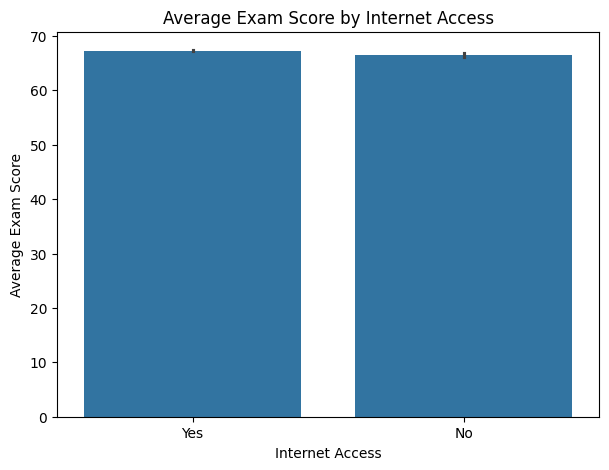

In [26]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="Internet_Access",
    y="Exam_Score",
    estimator="mean"
)

plt.title("Average Exam Score by Internet Access")
plt.xlabel("Internet Access")
plt.ylabel("Average Exam Score")

plt.show()

In [27]:
print(df["Internet_Access"].value_counts())

Internet_Access
Yes    6108
No      499
Name: count, dtype: int64


In [28]:
extracurricular_scores = df.groupby(
    "Extracurricular_Activities"
)["Exam_Score"].mean()

print(extracurricular_scores)

Extracurricular_Activities
No     66.931435
Yes    67.441849
Name: Exam_Score, dtype: float64


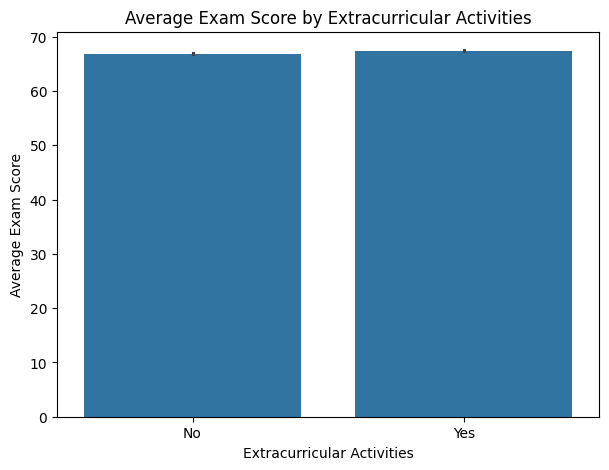

In [29]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="Extracurricular_Activities",
    y="Exam_Score",
    estimator="mean"
)

plt.title("Average Exam Score by Extracurricular Activities")
plt.xlabel("Extracurricular Activities")
plt.ylabel("Average Exam Score")

plt.show()

In [30]:
print(df["Extracurricular_Activities"].value_counts())

Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64


In [31]:
motivation_scores = df.groupby(
    "Motivation_Level"
)["Exam_Score"].mean().sort_values(ascending=False)

print(motivation_scores)

Motivation_Level
High      67.704321
Medium    67.330648
Low       66.752194
Name: Exam_Score, dtype: float64


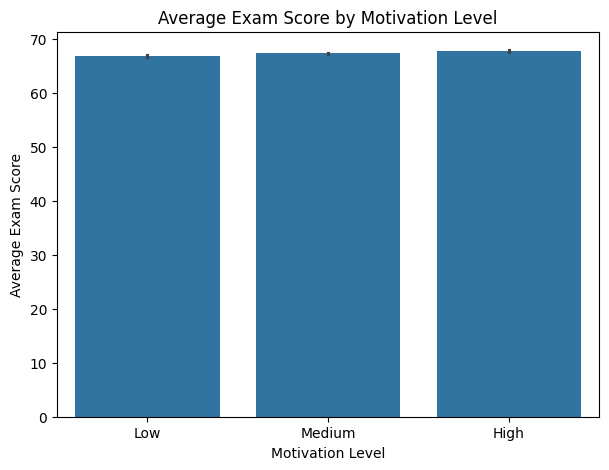

In [32]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="Motivation_Level",
    y="Exam_Score",
    estimator="mean"
)

plt.title("Average Exam Score by Motivation Level")
plt.xlabel("Motivation Level")
plt.ylabel("Average Exam Score")

plt.show()

In [33]:
print(df["Motivation_Level"].value_counts())

Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64


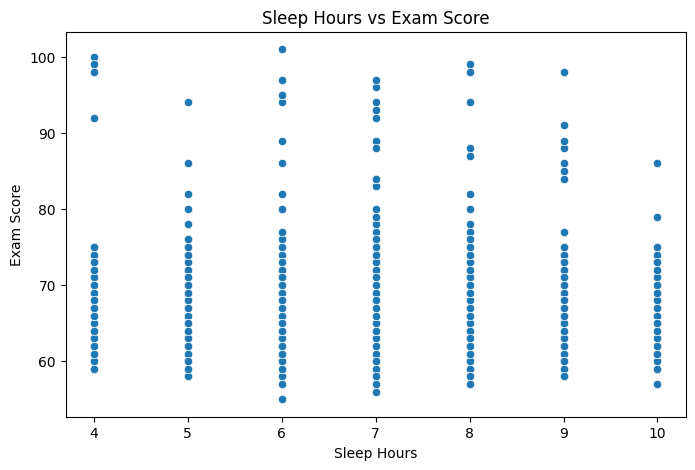

In [34]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Sleep_Hours",
    y="Exam_Score"
)

plt.title("Sleep Hours vs Exam Score")
plt.xlabel("Sleep Hours")
plt.ylabel("Exam Score")

plt.show()

In [35]:
sleep_corr = df["Sleep_Hours"].corr(df["Exam_Score"])

print("Correlation between Sleep Hours and Exam Score:", sleep_corr)

Correlation between Sleep Hours and Exam Score: -0.01702162857150255


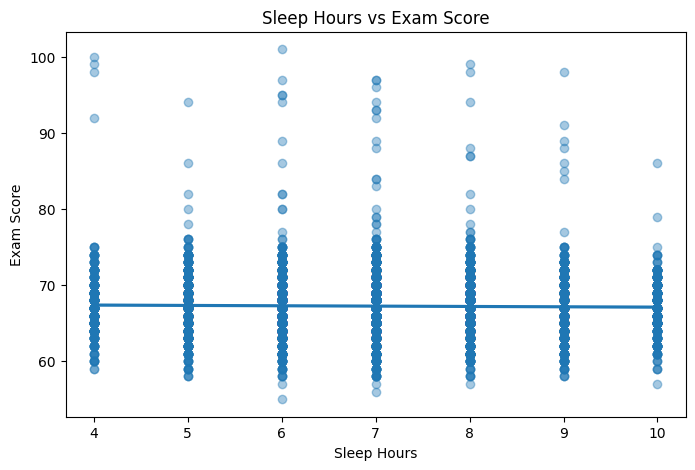

In [36]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="Sleep_Hours",
    y="Exam_Score",
    scatter_kws={"alpha": 0.4}
)

plt.title("Sleep Hours vs Exam Score")
plt.xlabel("Sleep Hours")
plt.ylabel("Exam Score")

plt.show()

In [37]:
tutoring_scores = df.groupby(
    "Tutoring_Sessions"
)["Exam_Score"].mean()

print(tutoring_scores)

Tutoring_Sessions
0    66.489755
1    66.980266
2    67.567010
3    67.894737
4    68.229236
5    69.067961
6    71.666667
7    69.857143
8    69.000000
Name: Exam_Score, dtype: float64


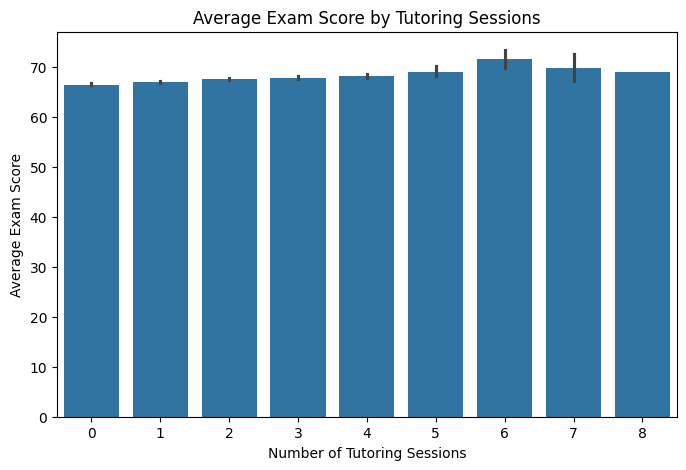

In [38]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Tutoring_Sessions",
    y="Exam_Score",
    estimator="mean"
)

plt.title("Average Exam Score by Tutoring Sessions")
plt.xlabel("Number of Tutoring Sessions")
plt.ylabel("Average Exam Score")

plt.show()

In [39]:
tutoring_corr = df["Tutoring_Sessions"].corr(df["Exam_Score"])

print(
    "Correlation between Tutoring Sessions and Exam Score:",
    tutoring_corr
)

Correlation between Tutoring Sessions and Exam Score: 0.15652518539225319


In [40]:
income_scores = df.groupby(
    "Family_Income"
)["Exam_Score"].mean().sort_values(ascending=False)

print(income_scores)

Family_Income
High      67.842396
Medium    67.334959
Low       66.848428
Name: Exam_Score, dtype: float64


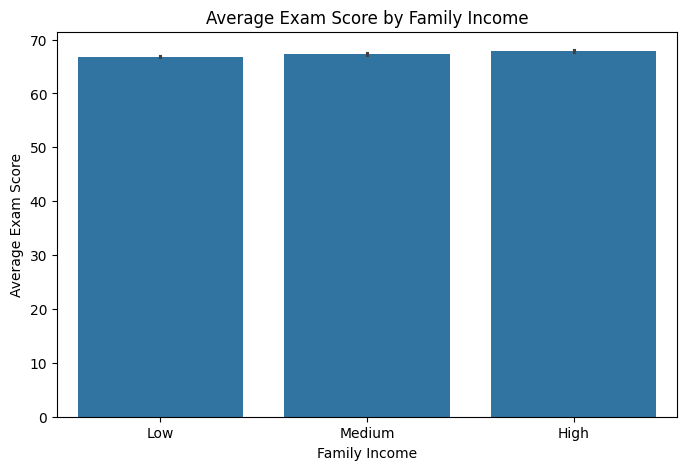

In [41]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Family_Income",
    y="Exam_Score",
    estimator="mean"
)

plt.title("Average Exam Score by Family Income")
plt.xlabel("Family Income")
plt.ylabel("Average Exam Score")

plt.show()

In [42]:
print(df["Family_Income"].value_counts())

Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64


In [43]:
resource_scores = df.groupby(
    "Access_to_Resources"
)["Exam_Score"].mean().sort_values(ascending=False)

print(resource_scores)

Access_to_Resources
High      68.092152
Medium    67.134378
Low       66.203351
Name: Exam_Score, dtype: float64


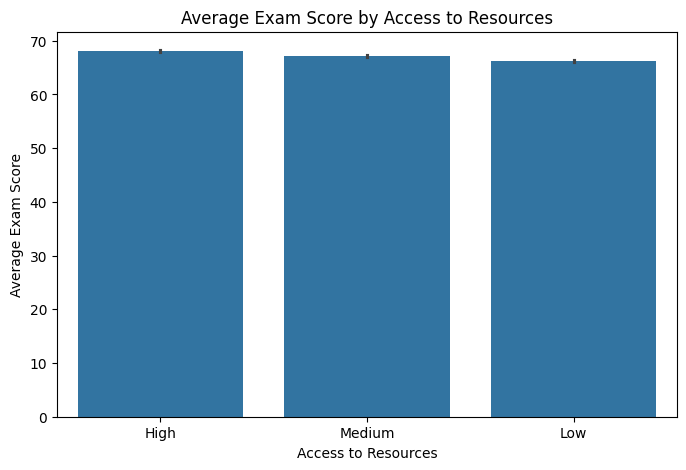

In [44]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Access_to_Resources",
    y="Exam_Score",
    estimator="mean"
)

plt.title("Average Exam Score by Access to Resources")
plt.xlabel("Access to Resources")
plt.ylabel("Average Exam Score")

plt.show()

In [45]:
print(df["Access_to_Resources"].value_counts())

Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64


In [46]:
peer_scores = df.groupby(
    "Peer_Influence"
)["Exam_Score"].mean().sort_values(ascending=False)

print(peer_scores)

Peer_Influence
Positive    67.623199
Neutral     67.197917
Negative    66.564270
Name: Exam_Score, dtype: float64


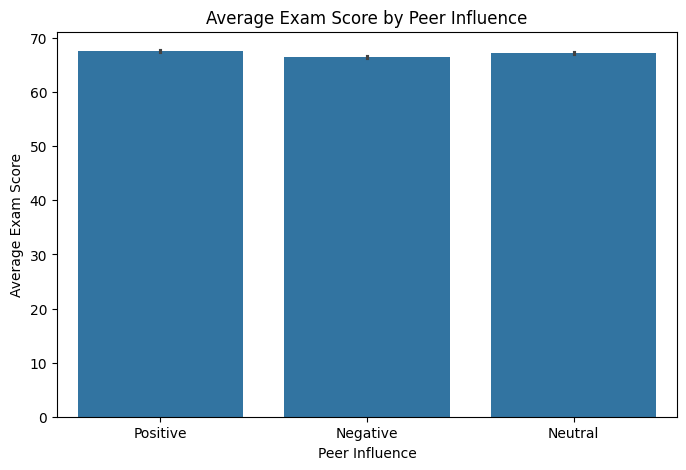

In [47]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Peer_Influence",
    y="Exam_Score",
    estimator="mean"
)

plt.title("Average Exam Score by Peer Influence")
plt.xlabel("Peer Influence")
plt.ylabel("Average Exam Score")

plt.show()

In [48]:
print(df["Peer_Influence"].value_counts())

Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64


In [49]:
numeric_columns = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity",
    "Exam_Score"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
Hours_Studied,1.000000,-0.009908,0.010977,0.024846,-0.014282,0.004624,0.445455
Attendance,-0.009908,1.000000,-0.015918,-0.020186,0.014324,-0.022435,0.581072
Sleep_Hours,0.010977,-0.015918,1.000000,-0.021750,-0.012216,-0.000378,-0.017022
Previous_Scores,0.024846,-0.020186,-0.021750,1.000000,-0.013122,-0.011274,0.175079
Tutoring_Sessions,-0.014282,0.014324,-0.012216,-0.013122,1.000000,0.017733,0.156525
Physical_Activity,0.004624,-0.022435,-0.000378,-0.011274,0.017733,1.000000,0.027824
Exam_Score,0.445455,0.581072,-0.017022,0.175079,0.156525,0.027824,1.000000


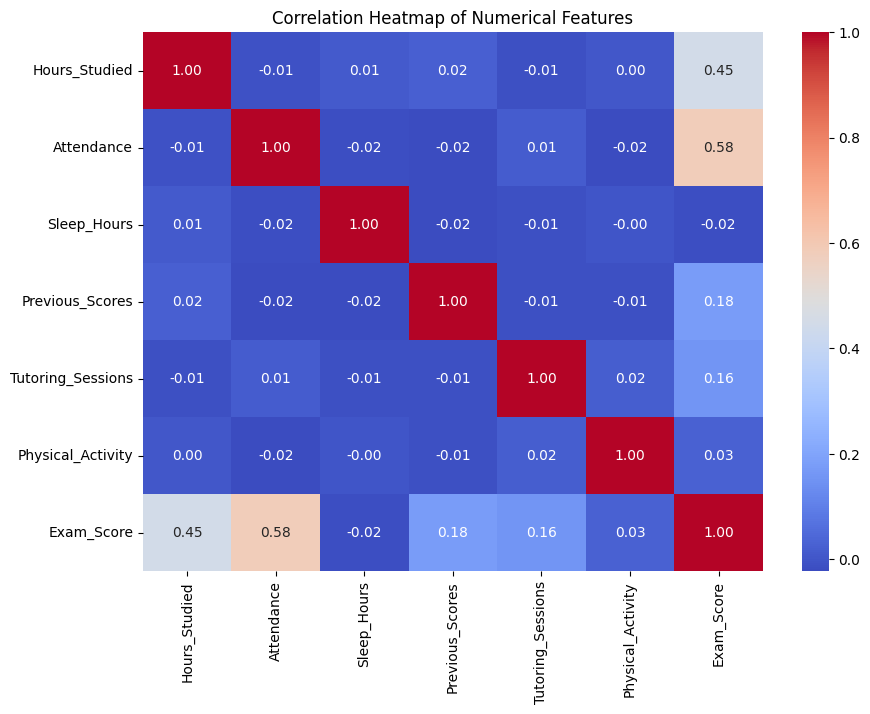

In [50]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

In [51]:
exam_correlations = (
    correlation_matrix["Exam_Score"]
    .drop("Exam_Score")
    .sort_values(key=abs, ascending=False)
)

print(exam_correlations)

Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022
Name: Exam_Score, dtype: float64


In [52]:
print(exam_correlations)

Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022
Name: Exam_Score, dtype: float64


In [53]:
df[df["Exam_Score"] > 100]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


In [54]:
print("Number of scores above 100:", (df["Exam_Score"] > 100).sum())

Number of scores above 100: 1


In [55]:
X = df.drop("Exam_Score", axis=1)
y = df["Exam_Score"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (6607, 19)
Target shape: (6607,)


In [56]:
categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_columns = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Numerical columns:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5285
Testing samples: 1322


In [58]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5285
Testing samples: 1322


In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [60]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ],
    remainder="passthrough"
)

In [61]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (5285, 40)
Encoded testing shape: (1322, 40)


In [62]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train_encoded,
    y_train
)

LinearRegression()

In [63]:
linear_predictions = linear_model.predict(X_test_encoded)

print(linear_predictions[:10])

[64.52628302 65.2651138  71.53126265 64.27748146 66.5216532  66.61246339
 72.47094891 66.49826901 69.98604472 70.13327106]


In [64]:
linear_model

LinearRegression()

In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, linear_predictions)
rmse = mean_squared_error(y_test, linear_predictions) ** 0.5
r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression Results
-------------------------
MAE : 0.4523920089625966
RMSE: 1.8044445092722838
R²  : 0.7696495724907313


In [66]:
from sklearn.tree import DecisionTreeRegressor

decision_tree = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

decision_tree.fit(
    X_train_encoded,
    y_train
)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [67]:
tree_predictions = decision_tree.predict(X_test_encoded)

print(tree_predictions[:10])

[65.51982379 66.28753181 70.61497326 65.78421053 64.8021978  66.35779817
 70.41441441 69.18055556 70.61497326 70.61497326]


In [68]:
tree_mae = mean_absolute_error(y_test, tree_predictions)
tree_rmse = mean_squared_error(y_test, tree_predictions) ** 0.5
tree_r2 = r2_score(y_test, tree_predictions)

print("Decision Tree Results")
print("--------------------")
print("MAE :", tree_mae)
print("RMSE:", tree_rmse)
print("R²  :", tree_r2)

Decision Tree Results
--------------------
MAE : 1.5917356707973453
RMSE: 2.537772021720446
R²  : 0.5443753934404274


In [69]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(
    X_train_encoded,
    y_train
)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [70]:
rf_predictions = random_forest.predict(X_test_encoded)

print(rf_predictions[:10])

[64.795 66.17  70.43  65.655 66.785 66.58  71.03  66.94  69.57  70.025]


In [71]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = mean_squared_error(y_test, rf_predictions) ** 0.5
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("--------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Results
--------------------
MAE : 1.0836838124054464
RMSE: 2.1607439132620367
R²  : 0.6697000126742456


In [72]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting.fit(
    X_train_encoded,
    y_train
)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

In [73]:
gb_predictions = gradient_boosting.predict(X_test_encoded)

print(gb_predictions[:10])

[64.93904157 65.52088538 70.68655344 65.03827469 66.29183185 66.76458888
 69.51139223 66.51883333 68.82304092 69.94768115]


In [74]:
gb_mae = mean_absolute_error(y_test, gb_predictions)
gb_rmse = mean_squared_error(y_test, gb_predictions) ** 0.5
gb_r2 = r2_score(y_test, gb_predictions)

print("Gradient Boosting Results")
print("------------------------")
print("MAE :", gb_mae)
print("RMSE:", gb_rmse)
print("R²  :", gb_r2)

Gradient Boosting Results
------------------------
MAE : 0.7897581126881542
RMSE: 1.9473741312887662
R²  : 0.7317123053708086


In [75]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mae,
        tree_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        rmse,
        tree_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        r2,
        tree_r2,
        rf_r2,
        gb_r2
    ]
})

model_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,0.452392,1.804445,0.769650
1,Decision Tree,1.591736,2.537772,0.544375
2,Random Forest,1.083684,2.160744,0.669700
3,Gradient Boosting,0.789758,1.947374,0.731712


In [76]:
model_comparison.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,RMSE,R2
0,Linear Regression,0.452392,1.804445,0.769650
3,Gradient Boosting,0.789758,1.947374,0.731712
2,Random Forest,1.083684,2.160744,0.669700
1,Decision Tree,1.591736,2.537772,0.544375


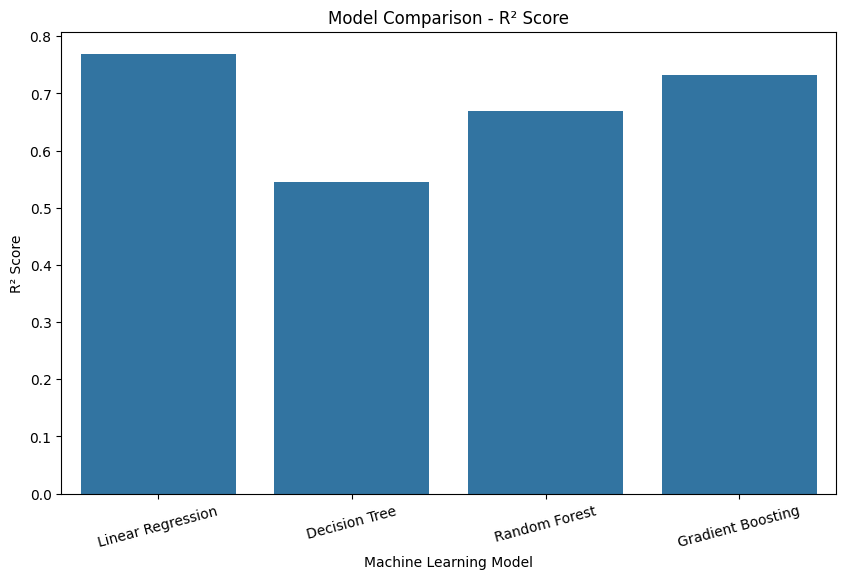

In [77]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="R2"
)

plt.title("Model Comparison - R² Score")
plt.xlabel("Machine Learning Model")
plt.ylabel("R² Score")
plt.xticks(rotation=15)

plt.show()

In [78]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))

Number of features: 40


In [79]:
feature_importance = pd.Series(
    random_forest.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

feature_importance.head(15)

,0
remainder__Attendance,0.374015
remainder__Hours_Studied,0.239887
remainder__Previous_Scores,0.084091
remainder__Tutoring_Sessions,0.033411
remainder__Physical_Activity,0.024810
remainder__Sleep_Hours,0.024691
categorical__Access_to_Resources_High,0.018804
categorical__Parental_Involvement_High,0.018061
categorical__Parental_Involvement_Low,0.013208
categorical__Access_to_Resources_Low,0.011086


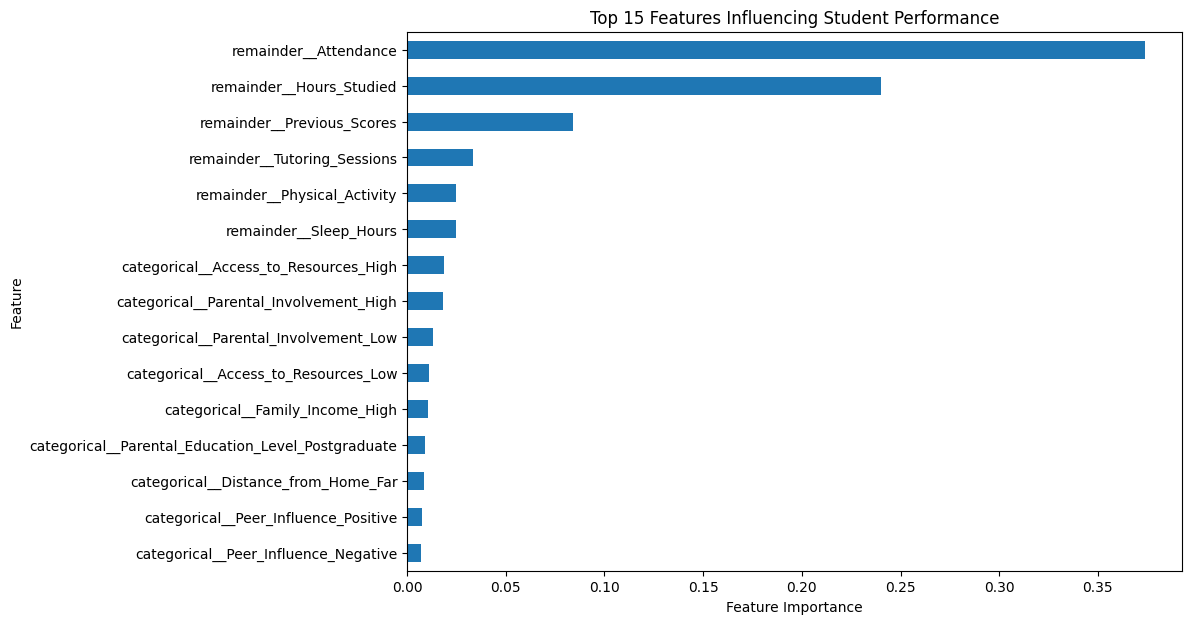

In [80]:
top_features = feature_importance.head(15).sort_values()

plt.figure(figsize=(10, 7))

top_features.plot(kind="barh")

plt.title("Top 15 Features Influencing Student Performance")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

In [81]:
feature_importance.head(15)

,0
remainder__Attendance,0.374015
remainder__Hours_Studied,0.239887
remainder__Previous_Scores,0.084091
remainder__Tutoring_Sessions,0.033411
remainder__Physical_Activity,0.024810
remainder__Sleep_Hours,0.024691
categorical__Access_to_Resources_High,0.018804
categorical__Parental_Involvement_High,0.018061
categorical__Parental_Involvement_Low,0.013208
categorical__Access_to_Resources_Low,0.011086


In [82]:
feature_importance.head(15)

,0
remainder__Attendance,0.374015
remainder__Hours_Studied,0.239887
remainder__Previous_Scores,0.084091
remainder__Tutoring_Sessions,0.033411
remainder__Physical_Activity,0.024810
remainder__Sleep_Hours,0.024691
categorical__Access_to_Resources_High,0.018804
categorical__Parental_Involvement_High,0.018061
categorical__Parental_Involvement_Low,0.013208
categorical__Access_to_Resources_Low,0.011086


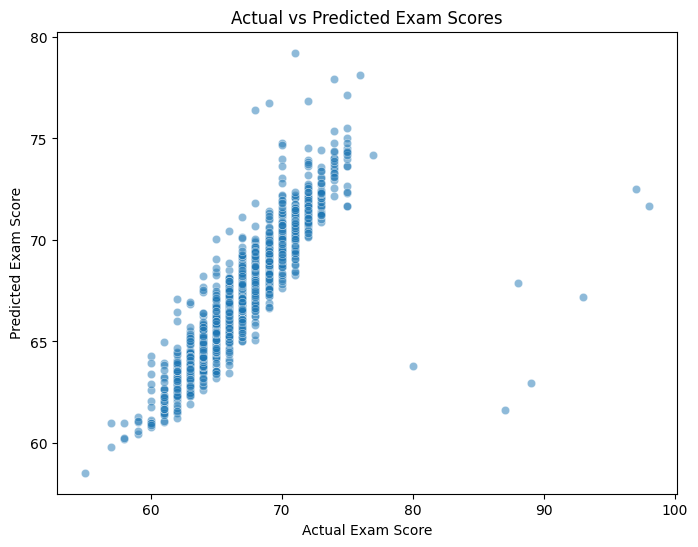

In [83]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=rf_predictions,
    alpha=0.5
)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")

plt.show()

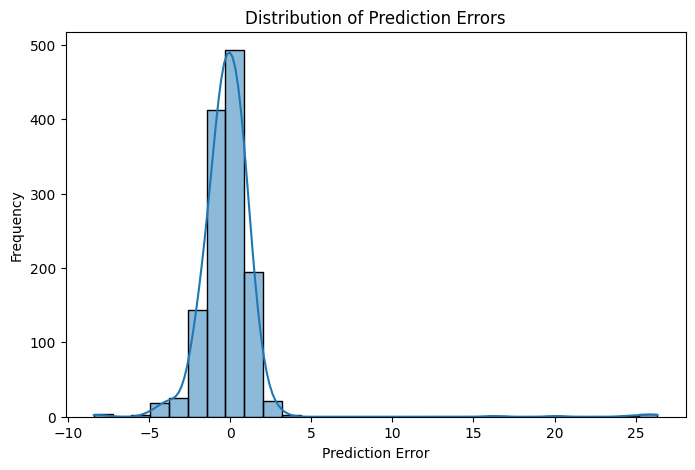

In [84]:
residuals = y_test - rf_predictions

plt.figure(figsize=(8, 5))

sns.histplot(residuals, bins=30, kde=True)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

In [85]:
final_comparison = model_comparison.copy()

final_comparison = final_comparison.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

final_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,0.452392,1.804445,0.769650
1,Gradient Boosting,0.789758,1.947374,0.731712
2,Random Forest,1.083684,2.160744,0.669700
3,Decision Tree,1.591736,2.537772,0.544375


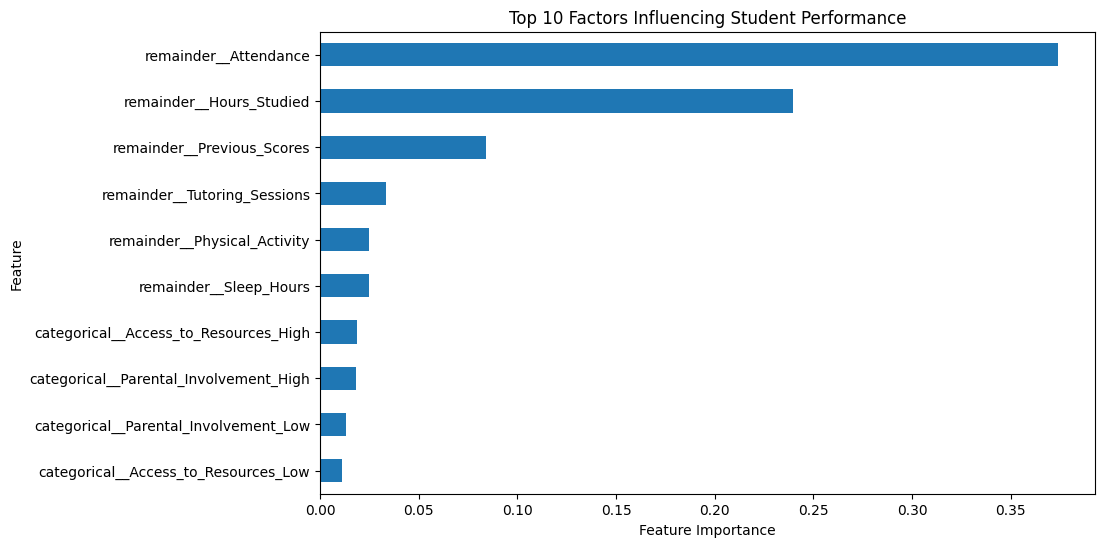

In [86]:
top_10_features = feature_importance.head(10).sort_values()

plt.figure(figsize=(10, 6))

top_10_features.plot(kind="barh")

plt.title("Top 10 Factors Influencing Student Performance")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

## Key Insights

1. Attendance showed the strongest positive relationship with Exam_Score
   among the numerical variables, with a correlation of approximately 0.581.

2. Hours_Studied showed the second strongest positive relationship with
   Exam_Score, with a correlation of approximately 0.445.

3. Previous_Scores and Tutoring_Sessions showed weaker positive
   relationships with current Exam_Score.

4. Physical_Activity showed a very weak relationship with Exam_Score.

5. Sleep_Hours showed an approximately negligible linear relationship
   with Exam_Score in this dataset.

6. The Random Forest feature-importance analysis also identified
   Attendance and Hours_Studied as the two most important individual
   features used by the model.

7. Categorical factors such as parental involvement, access to resources,
   family income, parental education, distance from home, and peer
   influence showed smaller individual feature-importance values than
   Attendance and Hours_Studied in the Random Forest model.

8. The machine-learning models were evaluated using MAE, RMSE, and R²
   to compare their predictive performance.

## Conclusion

This project analyzed student academic performance using academic,
behavioral, and demographic factors.

The analysis included data cleaning, exploratory data analysis,
visualization, and machine learning-based prediction.

The results showed that Attendance and Hours_Studied had the strongest
observed relationships with Exam_Score among the numerical variables.
The machine learning models provided a way to predict student
performance using multiple factors simultaneously.

Different regression models were trained and compared using MAE, RMSE,
and R². Feature-importance analysis from the Random Forest model
provided additional insight into the variables that contributed most
to the model's predictions.

Overall, the project demonstrates how data analytics and machine
learning can be used to analyze patterns in student performance and
support data-driven understanding of academic outcomes.

In [92]:
final_comparison = model_comparison.copy()

final_comparison = final_comparison.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

final_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,0.452392,1.804445,0.769650
1,Gradient Boosting,0.789758,1.947374,0.731712
2,Random Forest,1.083684,2.160744,0.669700
3,Decision Tree,1.591736,2.537772,0.544375


## Model Performance Comparison

Four regression models were trained and evaluated using Mean Absolute
Error (MAE), Root Mean Squared Error (RMSE), and R² score.

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Linear Regression | 0.4524 | 1.8044 | 0.7696 |
| Gradient Boosting | 0.7898 | 1.9474 | 0.7317 |
| Random Forest | 1.0837 | 2.1607 | 0.6697 |
| Decision Tree | 1.5917 | 2.5378 | 0.5444 |

For this experiment, Linear Regression produced the lowest MAE and RMSE
and the highest R² score among the four tested models.